In [1]:
import numpy as np
import pandas as pd

### Groupby:

- The study of groups, to groups together.
- This groupby is similar to groupby in sql.
- In groupby we forms groups in data on the basis of some column.(it is applied on categorical data/column)
- Its process is: Split,Apply and Combine
- **Splitting**:
  - The DataFrame is divided into groups based on specified criteria, such as the values in one or more columns.

- **Applying**:
  - A function is applied to each group independently. This could be an aggregation function (e.g., `sum()`, `mean()`, `count()`), a transformation function, or a custom function.

- **Combining**:
  - The results from each group are combined into a new DataFrame. The structure of this DataFrame depends on the applied fun

- 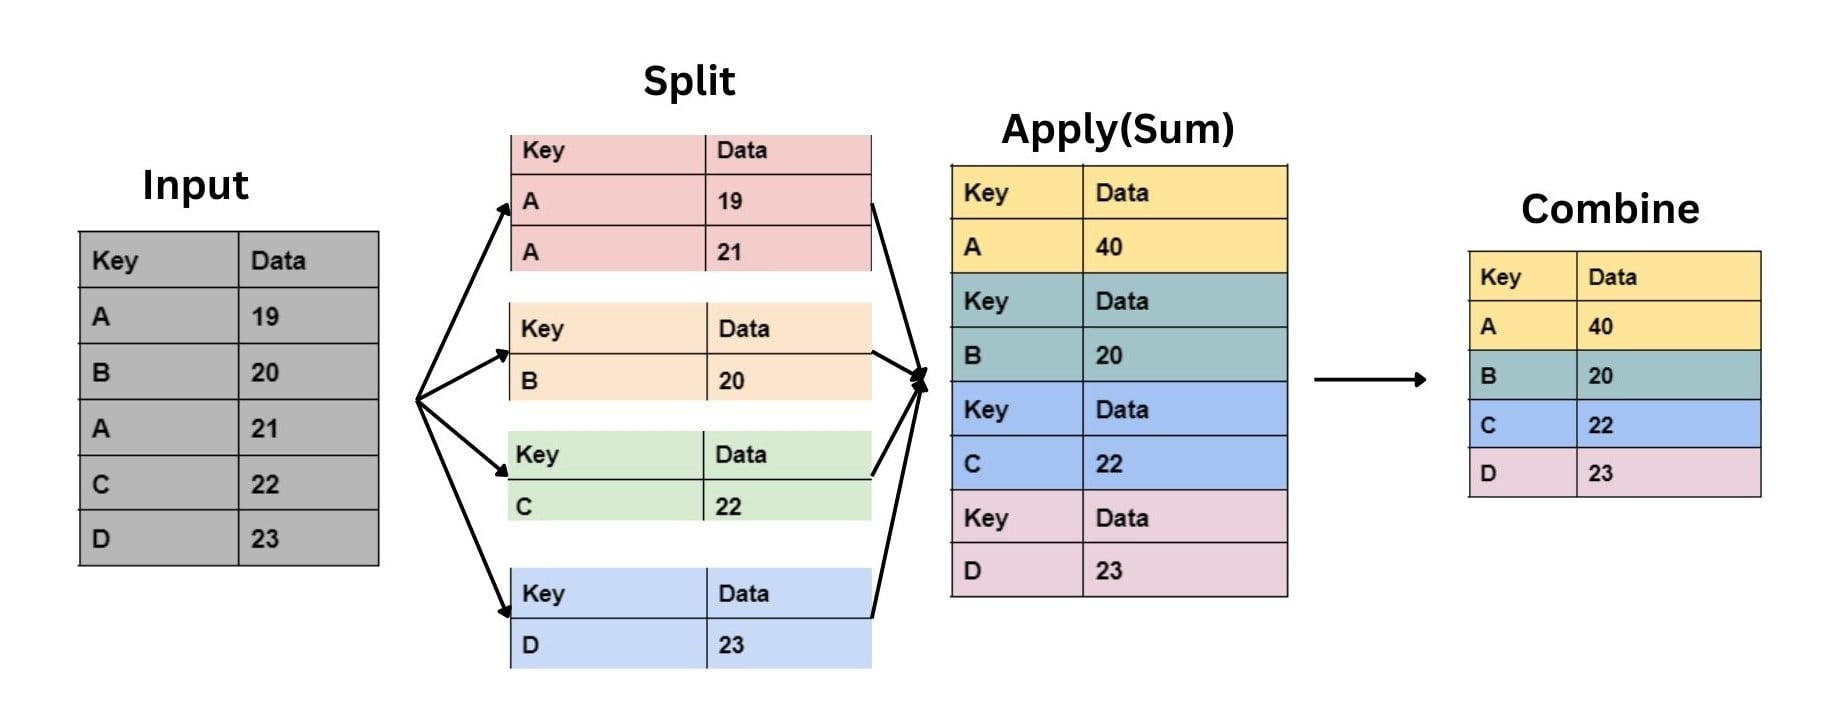




- 🔹 By default, groupby() jo column use karta hai, wo index ban jata hai.
- 🔹 Agar index nahi chahiye, toh as_index=False ya .reset_index() use kar sakte ho.ction.
tion.

In [3]:
movies =pd.read_csv("imdb-top-1000.csv")
movies.head(4)

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129952,57300000.0,90.0


In [4]:
movies.shape

(1000, 10)

In [8]:
genres=movies.groupby('Genre')
genres

In [5]:
''' applying builting aggregation function on groupby objects'''
genres.sum(numeric_only=True)

NameError: name 'genres' is not defined

In [12]:
genres.min()

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,300,1924,45,7.6,Abhishek Chaubey,Aamir Khan,25312,3296.0,33.0
Adventure,2001: A Space Odyssey,1925,88,7.6,Akira Kurosawa,Aamir Khan,29999,61001.0,41.0
Animation,Akira,1940,71,7.6,Adam Elliot,Adrian Molina,25229,128985.0,61.0
Biography,12 Years a Slave,1928,93,7.6,Adam McKay,Adrien Brody,27254,21877.0,48.0
Comedy,(500) Days of Summer,1921,68,7.6,Alejandro G. Iñárritu,Aamir Khan,26337,1305.0,45.0
Crime,12 Angry Men,1931,80,7.6,Akira Kurosawa,Ajay Devgn,27712,6013.0,47.0
Drama,1917,1925,64,7.6,Aamir Khan,Abhay Deol,25088,3600.0,28.0
Family,E.T. the Extra-Terrestrial,1971,100,7.8,Mel Stuart,Gene Wilder,178731,4000000.0,67.0
Fantasy,Das Cabinet des Dr. Caligari,1920,76,7.9,F.W. Murnau,Max Schreck,57428,337574718.0,NaN


In [14]:
movies.groupby?

Signature:
movies.groupby(
    by=None,
    axis: 'Axis | lib.NoDefault' = <no_default>,
    level: 'IndexLabel | None' = None,
    as_index: 'bool' = True,
    sort: 'bool' = True,
    group_keys: 'bool' = True,
    observed: 'bool | lib.NoDefault' = <no_default>,
    dropna: 'bool' = True,
) -> 'DataFrameGroupBy'
Docstring:
Group DataFrame using a mapper or by a Series of columns.

A groupby operation involves some combination of splitting the
object, applying a function, and combining the results. This can be
used to group large amounts of data and compute operations on these
groups.

Parameters
----------
by : mapping, function, label, pd.Grouper or list of such
    Used to determine the groups for the groupby.
    If ``by`` is a function, it's called on each value of the object's
    index. If a dict or Series is passed, the Series or dict VALUES
    will be used to determine the groups (the Series' values are first
    aligned; see ``.align()`` method). If a list or ndarray of le

In [16]:
genres.mean?

Signature:
genres.mean(
    numeric_only: 'bool' = False,
    engine: "Literal['cython', 'numba'] | None" = None,
    engine_kwargs: 'dict[str, bool] | None' = None,
)
Docstring:
Compute mean of groups, excluding missing values.

Parameters
----------
numeric_only : bool, default False
    Include only float, int, boolean columns.

    .. versionchanged:: 2.0.0

        numeric_only no longer accepts ``None`` and defaults to ``False``.

engine : str, default None
    * ``'cython'`` : Runs the operation through C-extensions from cython.
    * ``'numba'`` : Runs the operation through JIT compiled code from numba.
    * ``None`` : Defaults to ``'cython'`` or globally setting
      ``compute.use_numba``

    .. versionadded:: 1.4.0

engine_kwargs : dict, default None
    * For ``'cython'`` engine, there are no accepted ``engine_kwargs``
    * For ``'numba'`` engine, the engine can accept ``nopython``, ``nogil``
      and ``parallel`` dictionary keys. The values must either be ``True`` or
 

In [18]:
genres.mean(numeric_only=True)

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
Genre,,,,,
Action,129.046512,7.949419,420246.581395,1.897224e+08,73.419580
Adventure,134.111111,7.937500,313557.819444,1.319017e+08,78.437500
Animation,99.585366,7.930488,268032.073171,1.784326e+08,81.093333
Biography,136.022727,7.938636,272805.045455,9.404952e+07,76.240506
Comedy,112.129032,7.901290,178195.658065,1.010572e+08,78.720000
Crime,126.392523,8.016822,313398.271028,7.899656e+07,77.080460
Drama,124.737024,7.957439,212343.612457,1.225259e+08,79.701245
Family,107.500000,7.800000,275610.500000,2.195553e+08,79.000000
Fantasy,85.000000,8.000000,73111.000000,3.913633e+08,NaN


In [7]:
''' find the top 3 genres by total earning'''
df=movies.groupby('Genre').sum(numeric_only=True)
df['Gross'].sort_values(ascending=False).head(3)

Genre
Drama     3.540997e+10
Action    3.263226e+10
Comedy    1.566387e+10
Name: Gross, dtype: float64

In [95]:
''' alternative method1'''
movies.groupby('Genre').sum()['Gross'].sort_values(ascending=False).head(3)
#in this first we are summing up all the columns and then selecting 'Gross'

Genre
Drama     3.540997e+10
Action    3.263226e+10
Comedy    1.566387e+10
Name: Gross, dtype: float64

In [17]:
m=movies.groupby('Genre')
m['Gross'].sum()

Genre
Action       3.263226e+10
Adventure    9.496922e+09
Animation    1.463147e+10
Biography    8.276358e+09
Comedy       1.566387e+10
Crime        8.452632e+09
Drama        3.540997e+10
Family       4.391106e+08
Fantasy      7.827267e+08
Film-Noir    1.259105e+08
Horror       1.034649e+09
Mystery      1.256417e+09
Thriller     1.755074e+07
Western      5.822151e+07
Name: Gross, dtype: float64

In [101]:
''' alternative method 2'''
movies.groupby('Genre')['Gross'].sum().sort_values(ascending=False).head(3)
#this method is fast 

Genre
Drama     3.540997e+10
Action    3.263226e+10
Comedy    1.566387e+10
Name: Gross, dtype: float64

In [111]:
''' find the genre with the highest avg IMDB rating'''
movies.groupby('Genre')['IMDB_Rating'].mean().sort_values(ascending=False).head(1)

Genre
Western    8.35
Name: IMDB_Rating, dtype: float64

In [119]:
''' find the director with most popularity'''
movies.groupby('Director')['No_of_Votes'].sum().sort_values(ascending=False).head(1)

Director
Christopher Nolan    11578345
Name: No_of_Votes, dtype: int64

In [143]:
''' higher rated movie of each genre'''
movies.groupby("Genre")["IMDB_Rating"].max()

Genre
Action       9.0
Adventure    8.6
Animation    8.6
Biography    8.9
Comedy       8.6
Crime        9.2
Drama        9.3
Family       7.8
Fantasy      8.1
Film-Noir    8.1
Horror       8.5
Mystery      8.4
Thriller     7.8
Western      8.8
Name: IMDB_Rating, dtype: float64

In [133]:
movies[(movies['IMDB_Rating']==9.0)&(movies.Genre=='Action')]

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0


In [158]:
''' number of movies done by each actor'''
#movies['Star1'].value_counts
movies.groupby('Star1')["Series_Title"].count().sort_values(ascending=False)

Star1
Tom Hanks             12
Robert De Niro        11
Clint Eastwood        10
Al Pacino             10
Leonardo DiCaprio      9
                      ..
Glen Hansard           1
Giuseppe Battiston     1
Giulietta Masina       1
Gerardo Taracena       1
Ömer Faruk Sorak       1
Name: Series_Title, Length: 660, dtype: int64

In [22]:
movies.groupby('Star1')["IMDB_Rating"].count().sort_values(ascending=False)

Star1
Tom Hanks             12
Robert De Niro        11
Clint Eastwood        10
Al Pacino             10
Leonardo DiCaprio      9
                      ..
Glen Hansard           1
Giuseppe Battiston     1
Giulietta Masina       1
Gerardo Taracena       1
Ömer Faruk Sorak       1
Name: IMDB_Rating, Length: 660, dtype: int64

#### <font color='red'>GroupBy Attributes and Methods</font>

In [173]:
''' find total number of groups -> len'''
print(len(movies.groupby('Genre')))
movies.Genre.nunique()

14


14

In [169]:
len(movies.groupby('Star1'))

660

In [175]:
''' numbers of rows in each group -> size'''
movies.groupby('Genre').size()

Genre
Action       172
Adventure     72
Animation     82
Biography     88
Comedy       155
Crime        107
Drama        289
Family         2
Fantasy        2
Film-Noir      3
Horror        11
Mystery       12
Thriller       1
Western        4
dtype: int64

In [181]:
movies['Genre'].value_counts().sort_index()

Genre
Action       172
Adventure     72
Animation     82
Biography     88
Comedy       155
Crime        107
Drama        289
Family         2
Fantasy        2
Film-Noir      3
Horror        11
Mystery       12
Thriller       1
Western        4
Name: count, dtype: int64

In [31]:
''' we can find the first /last nth item of group'''
g=movies.groupby('Genre')
g.first() #it give the firtst movie in each group.

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,The Dark Knight,2008,152,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
Adventure,Interstellar,2014,169,8.6,Christopher Nolan,Matthew McConaughey,1512360,188020017.0,74.0
Animation,Sen to Chihiro no kamikakushi,2001,125,8.6,Hayao Miyazaki,Daveigh Chase,651376,10055859.0,96.0
Biography,Schindler's List,1993,195,8.9,Steven Spielberg,Liam Neeson,1213505,96898818.0,94.0
Comedy,Gisaengchung,2019,132,8.6,Bong Joon Ho,Kang-ho Song,552778,53367844.0,96.0
Crime,The Godfather,1972,175,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
Drama,The Shawshank Redemption,1994,142,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
Family,E.T. the Extra-Terrestrial,1982,115,7.8,Steven Spielberg,Henry Thomas,372490,435110554.0,91.0
Fantasy,Das Cabinet des Dr. Caligari,1920,76,8.1,Robert Wiene,Werner Krauss,57428,337574718.0,NaN


In [29]:
g.last()

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,Escape from Alcatraz,1979,112,7.6,Don Siegel,Clint Eastwood,121731,43000000.0,76.0
Adventure,Kelly's Heroes,1970,144,7.6,Brian G. Hutton,Clint Eastwood,45338,1378435.0,50.0
Animation,The Jungle Book,1967,78,7.6,Wolfgang Reitherman,Phil Harris,166409,141843612.0,65.0
Biography,Midnight Express,1978,121,7.6,Alan Parker,Brad Davis,73662,35000000.0,59.0
Comedy,Breakfast at Tiffany's,1961,115,7.6,Blake Edwards,Audrey Hepburn,166544,679874270.0,76.0
Crime,The 39 Steps,1935,86,7.6,Alfred Hitchcock,Robert Donat,51853,302787539.0,93.0
Drama,Lifeboat,1944,97,7.6,Alfred Hitchcock,Tallulah Bankhead,26471,852142728.0,78.0
Family,Willy Wonka & the Chocolate Factory,1971,100,7.8,Mel Stuart,Gene Wilder,178731,4000000.0,67.0
Fantasy,Nosferatu,1922,94,7.9,F.W. Murnau,Max Schreck,88794,445151978.0,NaN


In [211]:
#  we can find nth item as well
g.nth(3)

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
6,Pulp Fiction,1994,154,Crime,8.9,Quentin Tarantino,John Travolta,1826188,107928762.0,94.0
10,The Lord of the Rings: The Fellowship of the Ring,2001,178,Action,8.8,Peter Jackson,Elijah Wood,1661481,315544750.0,92.0
17,One Flew Over the Cuckoo's Nest,1975,133,Drama,8.7,Milos Forman,Jack Nicholson,918088,112000000.0,83.0
35,The Intouchables,2011,112,Biography,8.5,Olivier Nakache,Éric Toledano,760360,13182281.0,57.0
52,City Lights,1931,87,Comedy,8.5,Charles Chaplin,Charles Chaplin,167839,19181.0,99.0
56,Kimi no na wa.,2016,106,Animation,8.4,Makoto Shinkai,Ryûnosuke Kamiki,194838,5017246.0,79.0
110,Das Boot,1981,149,Adventure,8.3,Wolfgang Petersen,Jürgen Prochnow,231855,11487676.0,86.0
145,Shutter Island,2010,138,Mystery,8.2,Martin Scorsese,Leonardo DiCaprio,1129894,128012934.0,63.0
419,The Exorcist,1973,122,Horror,8.0,William Friedkin,Ellen Burstyn,362393,232906145.0,81.0
691,The Outlaw Josey Wales,1976,135,Western,7.8,Clint Eastwood,Clint Eastwood,65659,31800000.0,69.0


In [215]:
'''get_group: using this we can see all the movies pf a particular group'''
g.get_group('Horror')

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
49,Psycho,1960,109,Horror,8.5,Alfred Hitchcock,Anthony Perkins,604211,32000000.0,97.0
75,Alien,1979,117,Horror,8.4,Ridley Scott,Sigourney Weaver,787806,78900000.0,89.0
271,The Thing,1982,109,Horror,8.1,John Carpenter,Kurt Russell,371271,13782838.0,57.0
419,The Exorcist,1973,122,Horror,8.0,William Friedkin,Ellen Burstyn,362393,232906145.0,81.0
544,Night of the Living Dead,1968,96,Horror,7.9,George A. Romero,Duane Jones,116557,89029.0,89.0
707,The Innocents,1961,100,Horror,7.8,Jack Clayton,Deborah Kerr,27007,2616000.0,88.0
724,Get Out,2017,104,Horror,7.7,Jordan Peele,Daniel Kaluuya,492851,176040665.0,85.0
844,Halloween,1978,91,Horror,7.7,John Carpenter,Donald Pleasence,233106,47000000.0,87.0
876,The Invisible Man,1933,71,Horror,7.7,James Whale,Claude Rains,30683,298791505.0,87.0
932,Saw,2004,103,Horror,7.6,James Wan,Cary Elwes,379020,56000369.0,46.0


In [219]:
g.get_group('Action')
# advantage of get_group is that we not need to group the dta again.


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
5,The Lord of the Rings: The Return of the King,2003,201,Action,8.9,Peter Jackson,Elijah Wood,1642758,377845905.0,94.0
8,Inception,2010,148,Action,8.8,Christopher Nolan,Leonardo DiCaprio,2067042,292576195.0,74.0
10,The Lord of the Rings: The Fellowship of the Ring,2001,178,Action,8.8,Peter Jackson,Elijah Wood,1661481,315544750.0,92.0
13,The Lord of the Rings: The Two Towers,2002,179,Action,8.7,Peter Jackson,Elijah Wood,1485555,342551365.0,87.0
...,...,...,...,...,...,...,...,...,...,...
968,Falling Down,1993,113,Action,7.6,Joel Schumacher,Michael Douglas,171640,40903593.0,56.0
979,Lethal Weapon,1987,109,Action,7.6,Richard Donner,Mel Gibson,236894,65207127.0,68.0
982,Mad Max 2,1981,96,Action,7.6,George Miller,Mel Gibson,166588,12465371.0,77.0
983,The Warriors,1979,92,Action,7.6,Walter Hill,Michael Beck,93878,22490039.0,65.0


In [221]:
movies[movies['Genre']=='Action'] #we have to perform filtering for atleaast 14 case

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
5,The Lord of the Rings: The Return of the King,2003,201,Action,8.9,Peter Jackson,Elijah Wood,1642758,377845905.0,94.0
8,Inception,2010,148,Action,8.8,Christopher Nolan,Leonardo DiCaprio,2067042,292576195.0,74.0
10,The Lord of the Rings: The Fellowship of the Ring,2001,178,Action,8.8,Peter Jackson,Elijah Wood,1661481,315544750.0,92.0
13,The Lord of the Rings: The Two Towers,2002,179,Action,8.7,Peter Jackson,Elijah Wood,1485555,342551365.0,87.0
...,...,...,...,...,...,...,...,...,...,...
968,Falling Down,1993,113,Action,7.6,Joel Schumacher,Michael Douglas,171640,40903593.0,56.0
979,Lethal Weapon,1987,109,Action,7.6,Richard Donner,Mel Gibson,236894,65207127.0,68.0
982,Mad Max 2,1981,96,Action,7.6,George Miller,Mel Gibson,166588,12465371.0,77.0
983,The Warriors,1979,92,Action,7.6,Walter Hill,Michael Beck,93878,22490039.0,65.0


In [229]:
''' groups : it gives a dictionary in which a key is group names and value is the list of index position of all the movies inside that group '''
g.groups #attribute

{'Action': [2, 5, 8, 10, 13, 14, 16, 29, 30, 31, 39, 42, 44, 55, 57, 59, 60, 63, 68, 72, 106, 109, 129, 130, 134, 140, 142, 144, 152, 155, 160, 161, 166, 168, 171, 172, 177, 181, 194, 201, 202, 216, 217, 223, 224, 236, 241, 262, 275, 294, 308, 320, 325, 326, 331, 337, 339, 340, 343, 345, 348, 351, 353, 356, 357, 362, 368, 369, 375, 376, 390, 410, 431, 436, 473, 477, 479, 482, 488, 493, 496, 502, 507, 511, 532, 535, 540, 543, 564, 569, 570, 573, 577, 582, 583, 602, 605, 608, 615, 623, ...], 'Adventure': [21, 47, 93, 110, 114, 116, 118, 137, 178, 179, 191, 193, 209, 226, 231, 247, 267, 273, 281, 300, 301, 304, 306, 323, 329, 361, 366, 377, 402, 406, 415, 426, 458, 470, 497, 498, 506, 513, 514, 537, 549, 552, 553, 566, 576, 604, 609, 618, 638, 647, 675, 681, 686, 692, 711, 713, 739, 755, 781, 797, 798, 851, 873, 884, 912, 919, 947, 957, 964, 966, 984, 991], 'Animation': [23, 43, 46, 56, 58, 61, 66, 70, 101, 135, 146, 151, 158, 170, 197, 205, 211, 213, 219, 229, 230, 242, 245, 246, 270, 33

In [231]:
''' describe '''
g.describe()

Runtime                                                              \
            count        mean        std    min     25%    50%     75%    max   
Genre                                                                           
Action      172.0  129.046512  28.500706   45.0  110.75  127.5  143.25  321.0   
Adventure    72.0  134.111111  33.317320   88.0  109.00  127.0  149.00  228.0   
Animation    82.0   99.585366  14.530471   71.0   90.00   99.5  106.75  137.0   
Biography    88.0  136.022727  25.514466   93.0  120.00  129.0  146.25  209.0   
Comedy      155.0  112.129032  22.946213   68.0   96.00  106.0  124.50  188.0   
Crime       107.0  126.392523  27.689231   80.0  106.50  122.0  141.50  229.0   
Drama       289.0  124.737024  27.740490   64.0  105.00  121.0  137.00  242.0   
Family        2.0  107.500000  10.606602  100.0  103.75  107.5  111.25  115.0   
Fantasy       2.0   85.000000  12.727922   76.0   80.50   85.0   89.50   94.0   
Film-Noir     3.0  104.000000   4.000000  100.0  102.00  104.0  106.00  108.0   
Horror       11.0  102.090909  13.604812   71.0   98.00  103.0  109.00  122.0   
Mystery      12.0  119.083333  14.475423   96.0  110.75  117.5  130.25  138.0   
Thriller      1.0  108.000000        NaN  108.0  108.00  108.0  108.00  108.0   
Western       4.0  148.250000  17.153717  132.0  134.25  148.0  162.00  165.0   

          IMDB_Rating            ...         Gross              Metascore  \
                count      mean  ...           75%          max     count   
Genre                            ...                                        
Action          172.0  7.949419  ...  2.674437e+08  936662225.0     143.0   
Adventure        72.0  7.937500  ...  1.998070e+08  874211619.0      64.0   
Animation        82.0  7.930488  ...  2.520612e+08  873839108.0      75.0   
Biography        88.0  7.938636  ...  9.829924e+07  753585104.0      79.0   
Comedy          155.0  7.901290  ...  8.107809e+07  886752933.0     125.0   
Crime           107.0  8.016822  ...  7.102163e+07  790482117.0      87.0   
Drama           289.0  7.957439  ...  1.164461e+08  924558264.0     241.0   
Family            2.0  7.800000  ...  3.273329e+08  435110554.0       2.0   
Fantasy           2.0  8.000000  ...  4.182577e+08  445151978.0       0.0   
Film-Noir         3.0  7.966667  ...  6.273068e+07  123353292.0       3.0   
Horror           11.0  7.909091  ...  1.362817e+08  298791505.0      11.0   
Mystery          12.0  7.975000  ...  1.310949e+08  474203697.0       8.0   
Thriller          1.0  7.800000  ...  1.755074e+07   17550741.0       1.0   
Western           4.0  8.350000  ...  1.920000e+07   31800000.0       4.0   

                                                                  
                mean        std   min    25%   50%    75%    max  
Genre                                                             
Action     73.419580  12.421252  33.0  65.00  74.0  82.00   98.0  
Adventure  78.437500  12.345393  41.0  69.75  80.5  87.25  100.0  
Animation  81.093333   8.813646  61.0  75.00  82.0  87.50   96.0  
Biography  76.240506  11.028187  48.0  70.50  76.0  84.50   97.0  
Comedy     78.720000  11.829160  45.0  72.00  79.0  88.00   99.0  
Crime      77.080460  13.099102  47.0  69.50  77.0  87.00  100.0  
Drama      79.701245  12.744687  28.0  72.00  82.0  89.00  100.0  
Family     79.000000  16.970563  67.0  73.00  79.0  85.00   91.0  
Fantasy          NaN        NaN   NaN    NaN   NaN    NaN    NaN  
Film-Noir  95.666667   1.527525  94.0  95.00  96.0  96.50   97.0  
Horror     80.000000  15.362291  46.0  77.50  87.0  88.50   97.0  
Mystery    79.125000  18.604435  52.0  65.25  77.0  98.50  100.0  
Thriller   81.000000        NaN  81.0  81.00  81.0  81.00   81.0  
Western    78.250000   9.032349  69.0  72.75  77.0  82.50   90.0  

[14 rows x 40 columns]

In [249]:
'''sample'''
g.sample() # ye randomly selected movies from each group by

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
29,Star Wars,1977,121,Action,8.6,George Lucas,Mark Hamill,1231473,322740140.0,90.0
991,Kelly's Heroes,1970,144,Adventure,7.6,Brian G. Hutton,Clint Eastwood,45338,1378435.0,50.0
409,Tenkû no shiro Rapyuta,1986,125,Animation,8.0,Hayao Miyazaki,Mayumi Tanaka,150140,715920290.0,78.0
657,Ed Wood,1994,127,Biography,7.8,Tim Burton,Johnny Depp,164937,5887457.0,70.0
945,The Royal Tenenbaums,2001,110,Comedy,7.6,Wes Anderson,Gene Hackman,266842,52364010.0,76.0
384,Dancer in the Dark,2000,140,Crime,8.0,Lars von Trier,Björk,102285,4184036.0,61.0
291,La battaglia di Algeri,1966,121,Drama,8.1,Gillo Pontecorvo,Brahim Hadjadj,53089,55908.0,96.0
688,E.T. the Extra-Terrestrial,1982,115,Family,7.8,Steven Spielberg,Henry Thomas,372490,435110554.0,91.0
568,Nosferatu,1922,94,Fantasy,7.9,F.W. Murnau,Max Schreck,88794,445151978.0,NaN
309,The Third Man,1949,104,Film-Noir,8.1,Carol Reed,Orson Welles,158731,449191.0,97.0


In [257]:
g.sample(2,replace=True)

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
357,The Avengers,2012,143,Action,8.0,Joss Whedon,Robert Downey Jr.,1260806,623279547.0,69.0
109,Star Wars: Episode VI - Return of the Jedi,1983,131,Action,8.3,Richard Marquand,Mark Hamill,950470,309125409.0,58.0
118,North by Northwest,1959,136,Adventure,8.3,Alfred Hitchcock,Cary Grant,299198,13275000.0,98.0
21,Interstellar,2014,169,Adventure,8.6,Christopher Nolan,Matthew McConaughey,1512360,188020017.0,74.0
592,Big Hero 6,2014,102,Animation,7.8,Don Hall,Chris Williams,410983,222527828.0,74.0
518,Mimi wo sumaseba,1995,111,Animation,7.9,Yoshifumi Kondô,Yoko Honna,51943,252243550.0,75.0
276,The Elephant Man,1980,124,Biography,8.1,David Lynch,Anthony Hopkins,220078,753585104.0,78.0
684,The Killing Fields,1984,141,Biography,7.8,Roland Joffé,Sam Waterston,51585,34700291.0,76.0
132,"Three Billboards Outside Ebbing, Missouri",2017,115,Comedy,8.2,Martin McDonagh,Frances McDormand,432610,54513740.0,88.0
660,The Sandlot,1993,101,Comedy,7.8,David Mickey Evans,Tom Guiry,78963,32416586.0,55.0


In [259]:
'''nunique : hr genre mai kitni unique values hai'''
g.nunique()

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,172,61,78,15,123,121,172,172,50
Adventure,72,49,58,10,59,59,72,72,33
Animation,82,35,41,11,51,77,82,82,29
Biography,88,44,56,13,76,72,88,88,40
Comedy,155,72,70,11,113,133,155,155,44
Crime,106,56,65,14,86,85,107,107,39
Drama,289,83,95,14,211,250,288,287,52
Family,2,2,2,1,2,2,2,2,2
Fantasy,2,2,2,2,2,2,2,2,0


#### aggregate method
- ek sth hum apne groupby ke uppr multiple aggregation functions lga skte hai
- if we want to apply different aggregation functions on different columns of a groupby then we use agg method.
- In this method we pass a dict with key as column name and value as which aggregate function we want to apply.


In [272]:
g.agg(
    {
        "Runtime":'mean',
        "IMDB_Rating":'mean',
        "No_of_Votes":'sum',
        "Gross":"sum",
        "Metascore":"min"})

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
Genre,,,,,
Action,129.046512,7.949419,72282412,3.263226e+10,33.0
Adventure,134.111111,7.937500,22576163,9.496922e+09,41.0
Animation,99.585366,7.930488,21978630,1.463147e+10,61.0
Biography,136.022727,7.938636,24006844,8.276358e+09,48.0
Comedy,112.129032,7.901290,27620327,1.566387e+10,45.0
Crime,126.392523,8.016822,33533615,8.452632e+09,47.0
Drama,124.737024,7.957439,61367304,3.540997e+10,28.0
Family,107.500000,7.800000,551221,4.391106e+08,67.0
Fantasy,85.000000,8.000000,146222,7.827267e+08,NaN


In [286]:
''' we want to apply 3 aggregation to a single column min ,max and average '''
g.agg(['min','max'])

Series_Title  \
                                       min   
Genre                                        
Action                                 300   
Adventure            2001: A Space Odyssey   
Animation                            Akira   
Biography                 12 Years a Slave   
Comedy                (500) Days of Summer   
Crime                         12 Angry Men   
Drama                                 1917   
Family          E.T. the Extra-Terrestrial   
Fantasy       Das Cabinet des Dr. Caligari   
Film-Noir                Shadow of a Doubt   
Horror                               Alien   
Mystery                          Dark City   
Thriller                   Wait Until Dark   
Western    Il buono, il brutto, il cattivo   

                                               Released_Year       Runtime  \
                                           max           min   max     min   
Genre                                                                        
Action                                 Yôjinbô          1924  2019      45   
Adventure                           Zombieland          1925    PG      88   
Animation          Ôkami kodomo no Ame to Yuki          1940  2020      71   
Biography                              Zerkalo          1928  2020      93   
Comedy                Zindagi Na Milegi Dobara          1921  2020      68   
Crime                        À bout de souffle          1931  2019      80   
Drama                                Zwartboek          1925  2020      64   
Family     Willy Wonka & the Chocolate Factory          1971  1982     100   
Fantasy                              Nosferatu          1920  1922      76   
Film-Noir                        The Third Man          1941  1949     100   
Horror                               The Thing          1933  2017      71   
Mystery                                Vertigo          1938  2012      96   
Thriller                       Wait Until Dark          1967  1967     108   
Western                 The Outlaw Josey Wales          1965  1976     132   

               IMDB_Rating                    Director                    \
           max         min  max                    min               max   
Genre                                                                      
Action     321         7.6  9.0       Abhishek Chaubey       Zack Snyder   
Adventure  228         7.6  8.6         Akira Kurosawa  Ömer Faruk Sorak   
Animation  137         7.6  8.6            Adam Elliot   Yoshifumi Kondô   
Biography  209         7.6  8.9             Adam McKay      Tom McCarthy   
Comedy     188         7.6  8.6  Alejandro G. Iñárritu       Zoya Akhtar   
Crime      229         7.6  9.2         Akira Kurosawa      Yavuz Turgul   
Drama      242         7.6  9.3             Aamir Khan       Çagan Irmak   
Family     115         7.8  7.8             Mel Stuart  Steven Spielberg   
Fantasy     94         7.9  8.1            F.W. Murnau      Robert Wiene   
Film-Noir  108         7.8  8.1       Alfred Hitchcock       John Huston   
Horror     122         7.6  8.5     Alejandro Amenábar  William Friedkin   
Mystery    138         7.6  8.4            Alex Proyas     Terry Gilliam   
Thriller   108         7.8  7.8          Terence Young     Terence Young   
Western    165         7.8  8.8         Clint Eastwood      Sergio Leone   

                              Star1                   No_of_Votes           \
                                min               max         min      max   
Genre                                                                        
Action                   Aamir Khan      Yun-Fat Chow       25312  2303232   
Adventure                Aamir Khan      Yves Montand       29999  1512360   
Animation             Adrian Molina      Yôji Matsuda       25229   999790   
Biography              Adrien Brody     Éric Toledano       27254  1213505   
Comedy                   Aamir Khan  Ömer Faruk Sorak       26337   939631   
Cri

In [288]:
g.agg(
    {
        "Runtime":['mean','min'],
        "IMDB_Rating":'mean',
        "No_of_Votes":['sum','max'],
        "Gross":"sum",
        "Metascore":"min"})

Runtime      IMDB_Rating No_of_Votes                  Gross  \
                 mean  min        mean         sum      max           sum   
Genre                                                                       
Action     129.046512   45    7.949419    72282412  2303232  3.263226e+10   
Adventure  134.111111   88    7.937500    22576163  1512360  9.496922e+09   
Animation   99.585366   71    7.930488    21978630   999790  1.463147e+10   
Biography  136.022727   93    7.938636    24006844  1213505  8.276358e+09   
Comedy     112.129032   68    7.901290    27620327   939631  1.566387e+10   
Crime      126.392523   80    8.016822    33533615  1826188  8.452632e+09   
Drama      124.737024   64    7.957439    61367304  2343110  3.540997e+10   
Family     107.500000  100    7.800000      551221   372490  4.391106e+08   
Fantasy     85.000000   76    8.000000      146222    88794  7.827267e+08   
Film-Noir  104.000000  100    7.966667      367215   158731  1.259105e+08   
Horror     102.090909   71    7.909091     3742556   787806  1.034649e+09   
Mystery    119.083333   96    7.975000     4203004  1129894  1.256417e+09   
Thriller   108.000000  108    7.800000       27733    27733  1.755074e+07   
Western    148.250000  132    8.350000     1289665   688390  5.822151e+07   

          Metascore  
                min  
Genre                
Action         33.0  
Adventure      41.0  
Animation      61.0  
Biography      48.0  
Comedy         45.0  
Crime          47.0  
Drama          28.0  
Family         67.0  
Fantasy         NaN  
Film-Noir      94.0  
Horror         46.0  
Mystery        52.0  
Thriller       81.0  
Western        69.0

### <font color='red'>looping on groups</font>

In [334]:
''' higher rated movie of each genre'''
df=pd.DataFrame(columns=movies.columns)
for group,data in g:
    f=data[data["IMDB_Rating"]==(data['IMDB_Rating'].max())]
    df=pd.concat([df,f])
df

C:\Users\acer\AppData\Local\Temp\ipykernel_27132\295908788.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df=pd.concat([df,f])


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
21,Interstellar,2014,169,Adventure,8.6,Christopher Nolan,Matthew McConaughey,1512360,188020017.0,74.0
23,Sen to Chihiro no kamikakushi,2001,125,Animation,8.6,Hayao Miyazaki,Daveigh Chase,651376,10055859.0,96.0
7,Schindler's List,1993,195,Biography,8.9,Steven Spielberg,Liam Neeson,1213505,96898818.0,94.0
19,Gisaengchung,2019,132,Comedy,8.6,Bong Joon Ho,Kang-ho Song,552778,53367844.0,96.0
26,La vita è bella,1997,116,Comedy,8.6,Roberto Benigni,Roberto Benigni,623629,57598247.0,59.0
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
688,E.T. the Extra-Terrestrial,1982,115,Family,7.8,Steven Spielberg,Henry Thomas,372490,435110554.0,91.0
698,Willy Wonka & the Chocolate Factory,1971,100,Family,7.8,Mel Stuart,Gene Wilder,178731,4000000.0,67.0


In [344]:
''' split->(apply)->combine
apply-> buiting function'''
g.apply(min) #min is builtin functi
# but we can also send our own built function.

C:\Users\acer\AppData\Local\Temp\ipykernel_27132\976709687.py:3: FutureWarning: The provided callable <built-in function min> is currently using np.minimum.reduce. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.minimum.reduce instead.
  g.apply(min)
C:\Users\acer\AppData\Local\Temp\ipykernel_27132\976709687.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g.apply(min)


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,,
Action,300,1924,45,Action,7.6,Abhishek Chaubey,Aamir Khan,25312,3296.0,NaN
Adventure,2001: A Space Odyssey,1925,88,Adventure,7.6,Akira Kurosawa,Aamir Khan,29999,61001.0,NaN
Animation,Akira,1940,71,Animation,7.6,Adam Elliot,Adrian Molina,25229,128985.0,NaN
Biography,12 Years a Slave,1928,93,Biography,7.6,Adam McKay,Adrien Brody,27254,21877.0,NaN
Comedy,(500) Days of Summer,1921,68,Comedy,7.6,Alejandro G. Iñárritu,Aamir Khan,26337,1305.0,NaN
Crime,12 Angry Men,1931,80,Crime,7.6,Akira Kurosawa,Ajay Devgn,27712,6013.0,NaN
Drama,1917,1925,64,Drama,7.6,Aamir Khan,Abhay Deol,25088,3600.0,NaN
Family,E.T. the Extra-Terrestrial,1971,100,Family,7.8,Mel Stuart,Gene Wilder,178731,4000000.0,67.0
Fantasy,Das Cabinet des Dr. Caligari,1920,76,Fantasy,7.9,F.W. Murnau,Max Schreck,57428,337574718.0,NaN


In [372]:
''' find the number of movies starting with A for each group'''
def match(group):
    return group["Series_Title"].str.startswith('A').sum()
    

In [374]:
g.apply(match)

C:\Users\acer\AppData\Local\Temp\ipykernel_27132\3208101321.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g.apply(match)


Genre
Action       10
Adventure     2
Animation     2
Biography     9
Comedy       14
Crime         4
Drama        21
Family        0
Fantasy       0
Film-Noir     0
Horror        1
Mystery       0
Thriller      0
Western       0
dtype: int64

In [414]:
def match2(group):
    series=group['Series_Title']
    f=[]
    for i in series:
        if i[0].startswith("A"):
            f.append(i[0])
    df=pd.Series(f)
    return df.shape[0]

In [416]:
g.apply(match2)

C:\Users\acer\AppData\Local\Temp\ipykernel_27132\2204871167.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g.apply(match2)


Genre
Action       10
Adventure     2
Animation     2
Biography     9
Comedy       14
Crime         4
Drama        21
Family        0
Fantasy       0
Film-Noir     0
Horror        1
Mystery       0
Thriller      0
Western       0
dtype: int64

In [426]:
''' find ranking of each movie in the group according to IMDB score'''
''' hr movie ko rank dena hai jo btayega ki uska khud ke genre mai konse rank pr hai movie on the basis of IMDB rating'''
def rank_movie(group):
    group['genre_rank']=group["IMDB_Rating"].rank(ascending=False)# ascending false means jiska sbse jada rating uski rank 1
    return group


In [428]:
g.apply(rank_movie)

C:\Users\acer\AppData\Local\Temp\ipykernel_27132\3820095138.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g.apply(rank_movie)


Series_Title Released_Year  \
Genre                                                                           
Action   2                                      The Dark Knight          2008   
         5        The Lord of the Rings: The Return of the King          2003   
         8                                            Inception          2010   
         10   The Lord of the Rings: The Fellowship of the Ring          2001   
         13               The Lord of the Rings: The Two Towers          2002   
...                                                         ...           ...   
Thriller 700                                    Wait Until Dark          1967   
Western  12                     Il buono, il brutto, il cattivo          1966   
         48                        Once Upon a Time in the West          1968   
         115                         Per qualche dollaro in più          1965   
         691                             The Outlaw Josey Wales          1976   

              Runtime     Genre  IMDB_Rating           Director  \
Genre                                                             
Action   2        152    Action          9.0  Christopher Nolan   
         5        201    Action          8.9      Peter Jackson   
         8        148    Action          8.8  Christopher Nolan   
         10       178    Action          8.8      Peter Jackson   
         13       179    Action          8.7      Peter Jackson   
...               ...       ...          ...                ...   
Thriller 700      108  Thriller          7.8      Terence Young   
Western  12       161   Western          8.8       Sergio Leone   
         48       165   Western          8.5       Sergio Leone   
         115      132   Western          8.3       Sergio Leone   
         691      135   Western          7.8     Clint Eastwood   

                          Star1  No_of_Votes        Gross  Metascore  \
Genre                                                                  
Action   2       Christian Bale      2303232  534858444.0       84.0   
         5          Elijah Wood      1642758  377845905.0       94.0   
         8    Leonardo DiCaprio      2067042  292576195.0       74.0   
         10         Elijah Wood      1661481  315544750.0       92.0   
         13         Elijah Wood      1485555  342551365.0       87.0   
...                         ...          ...          ...        ...   
Thriller 700     Audrey Hepburn        27733   17550741.0       81.0   
Western  12      Clint Eastwood       688390    6100000.0       90.0   
         48         Henry Fonda       302844    5321508.0       80.0   
         115     Clint Eastwood       232772   15000000.0       74.0   
         691     Clint Eastwood        65659   31800000.0       69.0   

              genre_rank  
Genre                     
Action   2           1.0  
         5           2.0  
         8           3.5  
         10          3.5  
         13          6.0  
...                  ...  
Thriller 700         1.0  
Western  12          1.0  
         48          2.0  
         115         3.0  
         691         4.0  

[1000 rows x 11 columns]

In [436]:
''' find normalized IMDB rating for group wise'''
''' normalized= X-Xmin/Xmax-Xmin'''
def normal(group):
    group['norm_rating']=(group["IMDB_Rating"]-group["IMDB_Rating"].min())/(group["IMDB_Rating"].max()-group["IMDB_Rating"].min())
    return group

In [438]:
g.apply(normal)

C:\Users\acer\AppData\Local\Temp\ipykernel_27132\737742105.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g.apply(normal)


Series_Title Released_Year  \
Genre                                                                           
Action   2                                      The Dark Knight          2008   
         5        The Lord of the Rings: The Return of the King          2003   
         8                                            Inception          2010   
         10   The Lord of the Rings: The Fellowship of the Ring          2001   
         13               The Lord of the Rings: The Two Towers          2002   
...                                                         ...           ...   
Thriller 700                                    Wait Until Dark          1967   
Western  12                     Il buono, il brutto, il cattivo          1966   
         48                        Once Upon a Time in the West          1968   
         115                         Per qualche dollaro in più          1965   
         691                             The Outlaw Josey Wales          1976   

              Runtime     Genre  IMDB_Rating           Director  \
Genre                                                             
Action   2        152    Action          9.0  Christopher Nolan   
         5        201    Action          8.9      Peter Jackson   
         8        148    Action          8.8  Christopher Nolan   
         10       178    Action          8.8      Peter Jackson   
         13       179    Action          8.7      Peter Jackson   
...               ...       ...          ...                ...   
Thriller 700      108  Thriller          7.8      Terence Young   
Western  12       161   Western          8.8       Sergio Leone   
         48       165   Western          8.5       Sergio Leone   
         115      132   Western          8.3       Sergio Leone   
         691      135   Western          7.8     Clint Eastwood   

                          Star1  No_of_Votes        Gross  Metascore  \
Genre                                                                  
Action   2       Christian Bale      2303232  534858444.0       84.0   
         5          Elijah Wood      1642758  377845905.0       94.0   
         8    Leonardo DiCaprio      2067042  292576195.0       74.0   
         10         Elijah Wood      1661481  315544750.0       92.0   
         13         Elijah Wood      1485555  342551365.0       87.0   
...                         ...          ...          ...        ...   
Thriller 700     Audrey Hepburn        27733   17550741.0       81.0   
Western  12      Clint Eastwood       688390    6100000.0       90.0   
         48         Henry Fonda       302844    5321508.0       80.0   
         115     Clint Eastwood       232772   15000000.0       74.0   
         691     Clint Eastwood        65659   31800000.0       69.0   

              norm_rating  
Genre                      
Action   2       1.000000  
         5       0.928571  
         8       0.857143  
         10      0.857143  
         13      0.785714  
...                   ...  
Thriller 700          NaN  
Western  12      1.000000  
         48      0.700000  
         115     0.500000  
         691     0.000000  

[1000 rows x 11 columns]

#### groupby on multiple columns

In [465]:
''' i want to convert my dataset into groups on the baisis of two groups as directors and actor combo'''
duo=movies.groupby(['Director','Star1'])
duo.size()

Director             Star1         
Aamir Khan           Amole Gupte       1
Aaron Sorkin         Eddie Redmayne    1
Abdellatif Kechiche  Léa Seydoux       1
Abhishek Chaubey     Shahid Kapoor     1
Abhishek Kapoor      Amit Sadh         1
                                      ..
Zaza Urushadze       Lembit Ulfsak     1
Zoya Akhtar          Hrithik Roshan    1
                     Vijay Varma       1
Çagan Irmak          Çetin Tekindor    1
Ömer Faruk Sorak     Cem Yilmaz        1
Length: 898, dtype: int64

In [463]:
len(duo) #number of combination/group

898

In [467]:
duo.get_group(('Zoya Akhtar','Hrithik Roshan'))

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
221,Zindagi Na Milegi Dobara,2011,155,Comedy,8.1,Zoya Akhtar,Hrithik Roshan,67927,3108485.0,NaN


In [497]:
''' find the combo of the most earning actor->director combo'''
duo['Gross'].sum().sort_values(ascending=False).reset_index().head(1)

,Director,Star1,Gross
0,Akira Kurosawa,Toshirô Mifune,2.999877e+09


In [495]:
''' find the best (in terms of metascore(avg)) actor->genre combo'''
movies.groupby(['Star1','Genre'])['Metascore'].mean().reset_index().sort_values('Metascore',ascending=False)

,Star1,Genre,Metascore
230,Ellar Coltrane,Drama,100.0
329,Humphrey Bogart,Drama,100.0
360,James Stewart,Mystery,100.0
77,Bertil Guve,Drama,100.0
590,Orson Welles,Drama,100.0
...,...,...,...
807,William Holden,Drama,NaN
812,Won Bin,Action,NaN
815,Yash,Action,NaN
826,Çetin Tekindor,Drama,NaN


In [501]:
duo.agg(['min','max'])

Series_Title  \
                                                           min   
Director            Star1                                        
Aamir Khan          Amole Gupte               Taare Zameen Par   
Aaron Sorkin        Eddie Redmayne  The Trial of the Chicago 7   
Abdellatif Kechiche Léa Seydoux                 La vie d'Adèle   
Abhishek Chaubey    Shahid Kapoor                  Udta Punjab   
Abhishek Kapoor     Amit Sadh                      Kai po che!   
...                                                        ...   
Zaza Urushadze      Lembit Ulfsak                  Mandariinid   
Zoya Akhtar         Hrithik Roshan    Zindagi Na Milegi Dobara   
                    Vijay Varma                      Gully Boy   
Çagan Irmak         Çetin Tekindor              Babam ve Oglum   
Ömer Faruk Sorak    Cem Yilmaz                        G.O.R.A.   

                                                               Released_Year  \
                                                           max           min   
Director            Star1                                                      
Aamir Khan          Amole Gupte               Taare Zameen Par          2007   
Aaron Sorkin        Eddie Redmayne  The Trial of the Chicago 7          2020   
Abdellatif Kechiche Léa Seydoux                 La vie d'Adèle          2013   
Abhishek Chaubey    Shahid Kapoor                  Udta Punjab          2016   
Abhishek Kapoor     Amit Sadh                      Kai po che!          2013   
...                                                        ...           ...   
Zaza Urushadze      Lembit Ulfsak                  Mandariinid          2013   
Zoya Akhtar         Hrithik Roshan    Zindagi Na Milegi Dobara          2011   
                    Vijay Varma                      Gully Boy          2019   
Çagan Irmak         Çetin Tekindor              Babam ve Oglum          2005   
Ömer Faruk Sorak    Cem Yilmaz                        G.O.R.A.          2004   

                                         Runtime           Genre             \
                                     max     min  max        min        max   
Director            Star1                                                     
Aamir Khan          Amole Gupte     2007     165  165      Drama      Drama   
Aaron Sorkin        Eddie Redmayne  2020     129  129      Drama      Drama   
Abdellatif Kechiche Léa Seydoux     2013     180  180      Drama      Drama   
Abhishek Chaubey    Shahid Kapoor   2016     148  148     Action     Action   
Abhishek Kapoor     Amit Sadh       2013     130  130      Drama      Drama   
...                                  ...     ...  ...        ...        ...   
Zaza Urushadze      Lembit Ulfsak   2013      87   87      Drama      Drama   
Zoya Akhtar         Hrithik Roshan  2011     155  155     Comedy     Comedy   
                    Vijay Varma     2019     154  154      Drama      Drama   
Çagan Irmak         Çetin Tekindor  2005     112  112      Drama      Drama   
Ömer Faruk Sorak    Cem Yilmaz      2004     127  127  Adventure  Adventure   

                                   IMDB_Rating      No_of_Votes          \
                                           min  max         min     max   
Director            Star1                                                 
Aamir Khan          Amole Gupte            8.4  8.4      168895  168895   
Aaron Sorkin        Eddie Redmayne         7.8  7.8       89896   89896   
Abdellatif Kechiche Léa Seydoux            7.7  7.7      138741  138741   
Abhishek Chaubey    Shahid Kapoor          7.8  7.8       27175   27175   
Abhishek Kapoor     Amit Sadh              7.7  7.7       32628   32628   
...                                        ...  ...         ...     ...   
Zaza Urushadze      Lembit Ulfsak          8.2  8.2       40382   40382   
Zoya Akhtar         Hrithik Roshan         8.1  8.1       67927   67927   
                    Vijay Varma            8.0  8.0       31886   31886 

In [39]:
import requests
from io import StringIO
file_id="1xzluAOVoDwpcFg0YiqF0EOUAh__SK2b4"
url=f"https://drive.google.com/uc?id={file_id}"
response=requests.get(url)
if response.status_code==200:
    csv_data=StringIO(response.text)
    ipl=pd.read_csv(csv_data)
else:
    print('failed to fetch the file')

In [51]:
ipl.head() #here each row is a ball of an ipl match

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [47]:
ipl.shape

(179078, 21)

In [96]:
'''find the top 10 batsman in terms of runs scored'''
gr=ipl.groupby('batsman')
new=gr['batsman_runs'].sum().sort_values(ascending=False) # in this meko find krns tha 
#total runs ek batsman ne kitne banaye

In [98]:
new.head(10)

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4632
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4446
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64

In [133]:
''' find the name of the batsman with the max number of sixes'''
sixes=ipl[ipl['batsman_runs']==6]
sixes

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
10,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,4,DA Warner,S Dhawan,A Choudhary,0,...,0,0,0,0,6,0,6,NaN,NaN,NaN
47,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,8,4,MC Henriques,S Dhawan,TM Head,0,...,0,0,0,0,6,0,6,NaN,NaN,NaN
75,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,13,2,Yuvraj Singh,MC Henriques,A Choudhary,0,...,0,0,0,0,6,0,6,NaN,NaN,NaN
89,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,15,3,Yuvraj Singh,MC Henriques,S Aravind,0,...,0,0,0,0,6,0,6,NaN,NaN,NaN
91,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,15,5,MC Henriques,Yuvraj Singh,S Aravind,0,...,0,0,0,0,6,0,6,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178987,11415,2,Chennai Super Kings,Mumbai Indians,6,4,SR Watson,SK Raina,SL Malinga,0,...,0,0,0,0,6,0,6,NaN,NaN,NaN
179048,11415,2,Chennai Super Kings,Mumbai Indians,16,1,DJ Bravo,SR Watson,SL Malinga,0,...,0,0,0,0,6,0,6,NaN,NaN,NaN
179061,11415,2,Chennai Super Kings,Mumbai Indians,18,2,SR Watson,DJ Bravo,KH Pandya,0,...,0,0,0,0,6,0,6,NaN,NaN,NaN
179062,11415,2,Chennai Super Kings,Mumbai Indians,18,3,SR Watson,DJ Bravo,KH Pandya,0,...,0,0,0,0,6,0,6,NaN,NaN,NaN


In [147]:
gr=sixes.groupby('batsman')
gr['batsman_runs'].count().sort_values(ascending=False).head(1) # yaha find jrna hai ki kitne baar 6 banaye na ki jitne baar 6 bnaya use sum krdo

batsman
CH Gayle    327
Name: batsman_runs, dtype: int64

In [212]:
'''find the batsman with most number of 4's and 6's in last 5 overs'''
new=ipl[ipl['over']>15]
new_run=new[(new['batsman_runs']==4)|(new['batsman_runs']==6)]
new_run.groupby('batsman')['batsman_runs'].count().sort_values(ascending=False)

batsman
MS Dhoni          340
AB de Villiers    208
RG Sharma         208
KA Pollard        206
V Kohli           160
                 ... 
KC Cariappa         1
Shivam Sharma       1
Shoaib Malik        1
T Curran            1
KJ Abbott           1
Name: batsman_runs, Length: 360, dtype: int64

In [236]:
'''find V kholi's record against all teams'''
temp=ipl[ipl['batsman']=='V Kohli']
team=temp.groupby('bowling_team')
team['batsman_runs'].sum().reset_index()

,bowling_team,batsman_runs
0,Chennai Super Kings,749
1,Deccan Chargers,306
2,Delhi Capitals,66
3,Delhi Daredevils,763
4,Gujarat Lions,283
5,Kings XI Punjab,636
6,Kochi Tuskers Kerala,50
7,Kolkata Knight Riders,675
8,Mumbai Indians,628
9,Pune Warriors,128


In [275]:
'''create a function that can return the highest score of any batsman'''
temp_df=ipl[ipl['batsman']=='V Kohli']
temp_df.groupby('match_id')['batsman_runs'].sum().sort_values(ascending=False).head(1)

match_id
626    113
Name: batsman_runs, dtype: int64

In [291]:
def highest(batsman):
    temp_df=ipl[ipl['batsman']==batsman]
    return temp_df.groupby('match_id')['batsman_runs'].sum().sort_values(ascending=False).head(1)
    

In [293]:
highest('MS Dhoni')

match_id
11330    89
Name: batsman_runs, dtype: int64

In [297]:
highest('R Sharma')

match_id
229    14
Name: batsman_runs, dtype: int64